# Target-mass reconstruction from exclusive $ep\to e'p'\pi^0$ events

This notebook reads the combined LH2 ROOT file, selects `is_exclusive_mcd_combined == 1`, reconstructs the incident electron, scattered electron, and $\pi^0$ four-vectors with the conventions in `src/analysis/nps_helper.h` and `nps_physics_var.h`, and solves

$$A^2=(k' + p_{\pi^0} - k)^2=(P-P')^2,$$

for a stationary target $P=(M_T,\mathbf{0})$. The recoil/scattered proton is not directly stored in this tree: its three-momentum is inferred as $\mathbf{p}'=-\mathbf{A}$ for the MCD-selected events, and its energy is placed on the proton mass shell, $E'=\sqrt{m_p^2+|\mathbf{p}'|^2}$. The squared equation gives

$$M_T=E'\pm\sqrt{|\mathbf{p}'|^2+A^2}.$$

The physical root is the one consistent with the unsquared time-component equation $A^0=M_T-E'$, namely $M_T=E'+A^0$. Natural units and metric $(+,-,-,-)$ are used. Because $m_p$ is used to put the recoil proton on shell and the same exclusivity information helped select the sample, this is a reconstruction/consistency diagnostic rather than an independent precision measurement of the proton mass.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot

ROOT_FILE = Path(
    "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/"
    "root_analysis_env_main/output/KinC_x60_4b_pepsi_15gev/"
    "KinC_x60_4b/root/combined_branches_LH2.root"
)
CONFIG_FILE = Path(
    "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/"
    "root_analysis_env_main/config/nps_dvcs_all_kins_main.csv"
)
PLOT_FILE = Path(
    "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/"
    "root_analysis_env_main/script/target_mass_is_exclusive_mcd_combined.png"
)
TREE_NAME = "physics"

M_E = 0.0005109989461  # electron mass [GeV]
M_P = 0.9382720813     # proton mass [GeV], matching nps_helper.h

assert ROOT_FILE.is_file(), ROOT_FILE
assert CONFIG_FILE.is_file(), CONFIG_FILE
ROOT_FILE

PosixPath('/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/KinC_x60_4b_pepsi_15gev/KinC_x60_4b/root/combined_branches_LH2.root')

## Load only the required branches and run settings

The combined tree stores HMS slopes and momentum deviation rather than the original `H.gtr.px/py/pz`. The per-run beam energy, central HMS momentum/angle, and NPS angle/distance therefore come from the production configuration CSV used by the analysis.

In [8]:
branches = [
    "run_number", "delta", "xptar", "yptar",
    "cluster_e_1", "cluster_x_1", "cluster_y_1",
    "cluster_e_2", "cluster_x_2", "cluster_y_2",
    "Q2", "t", "mpi0_all", "mmiss_all", "pi0_weight",
    "is_exclusive_mcd_combined",
]

with uproot.open(ROOT_FILE) as root_file:
    tree = root_file[TREE_NAME]
    missing = sorted(set(branches) - set(tree.keys()))
    if missing:
        raise KeyError(f"Missing required branches: {missing}")
    data = tree.arrays(branches, library="np")

cfg = pd.read_csv(CONFIG_FILE, skipinitialspace=True)
cfg.columns = cfg.columns.str.strip()
for col in cfg.select_dtypes(include="object").columns:
    cfg[col] = cfg[col].str.strip()
cfg["run_number"] = pd.to_numeric(cfg["run_number"], errors="coerce")

setting_columns = [
    "run_number", "BeamEnergy", "HMS_P", "HMS_Thet",
    "NPS_Thet", "NPS_target_distance",
]
settings = (
    cfg.loc[(cfg["Kin_old"] == "KinC_x60_4b") & (cfg["target"] == "LH2"), setting_columns]
    .dropna(subset=["run_number"])
    .drop_duplicates(subset="run_number")
    .set_index("run_number")
)
for col in setting_columns[1:]:
    settings[col] = pd.to_numeric(settings[col], errors="raise")

event_runs = data["run_number"].astype(np.int64)
missing_runs = sorted(set(np.unique(event_runs)) - set(settings.index.astype(int)))
if missing_runs:
    raise KeyError(f"No production settings found for runs: {missing_runs}")

def event_setting(column):
    lookup = settings[column].to_dict()
    return np.fromiter((lookup[int(run)] for run in event_runs), dtype=float, count=len(event_runs))

ebeam = event_setting("BeamEnergy")
hms_p0 = event_setting("HMS_P")
hms_theta_deg = event_setting("HMS_Thet")
nps_theta_deg = event_setting("NPS_Thet")
z_nps_cm = event_setting("NPS_target_distance")

print(f"Loaded {len(event_runs):,} events from {len(np.unique(event_runs))} runs.")
print(f"MCD-selected events: {np.count_nonzero(data['is_exclusive_mcd_combined'] == 1):,}")

Loaded 111,593 events from 42 runs.
MCD-selected events: 28,660


/scratch/singhav/ipykernel_2816446/773989353.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in cfg.select_dtypes(include="object").columns:


## Four-vector reconstruction

The helper rotation is $R_y(\theta)(x,y,z)=(c x-s z, y, s x+c z)$. For HMS, the target-frame direction matching the production `H.gtr.px/py/pz` and stored $Q^2$ is proportional to `(yptar, -xptar, 1)` and rotated by `+HMS_Thet`. For NPS, each photon direction is proportional to `(cluster_x, cluster_y, z_NPS)` and is rotated by `-NPS_Thet`, exactly as in the analysis helper calls.

In [9]:
def rotate_y(momentum, angle_deg):
    """Vectorized copy of nps::rotate_y for arrays shaped (N, 3)."""
    angle = np.deg2rad(np.asarray(angle_deg, dtype=float))
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = momentum.T
    return np.column_stack((c * x - s * z, y, s * x + c * z))

def mass2(p4):
    """Invariant mass squared with metric (+, -, -, -)."""
    return p4[:, 0] ** 2 - np.einsum("ij,ij->i", p4[:, 1:], p4[:, 1:])

def photon_p4(energy, x_cm, y_cm, z_cm, rotation_deg):
    direction = np.column_stack((x_cm, y_cm, z_cm))
    direction /= np.linalg.norm(direction, axis=1)[:, None]
    momentum_hall = rotate_y(energy[:, None] * direction, rotation_deg)
    return np.column_stack((energy, momentum_hall))

# Incident electron: beam along +z.
p_beam = np.sqrt(np.maximum(0.0, ebeam**2 - M_E**2))
p4_e_in = np.column_stack((ebeam, np.zeros((len(ebeam), 2)), p_beam))

# Scattered electron from the HMS central momentum, delta, and target slopes.
p_e = hms_p0 * (1.0 + data["delta"] / 100.0)
hms_norm = np.sqrt(1.0 + data["xptar"]**2 + data["yptar"]**2)
p_e_hms = np.column_stack((
    p_e * data["yptar"] / hms_norm,
    -p_e * data["xptar"] / hms_norm,
    p_e / hms_norm,
))
p_e_hall = rotate_y(p_e_hms, hms_theta_deg)
e_e_out = np.sqrt(p_e**2 + M_E**2)
p4_e_out = np.column_stack((e_e_out, p_e_hall))

# pi0 = gamma1 + gamma2, with the production NPS-to-hall rotation sign.
p4_gamma1 = photon_p4(
    data["cluster_e_1"], data["cluster_x_1"], data["cluster_y_1"],
    z_nps_cm, -nps_theta_deg,
)
p4_gamma2 = photon_p4(
    data["cluster_e_2"], data["cluster_x_2"], data["cluster_y_2"],
    z_nps_cm, -nps_theta_deg,
)
p4_pi0 = p4_gamma1 + p4_gamma2

# A = k' + pi0 - k = P - P'.
A = p4_e_out + p4_pi0 - p4_e_in
t_calc = mass2(A)

# Recoil/scattered proton: infer three-momentum, then impose P'^2 = m_p^2.
p_recoil = -A[:, 1:]
p_recoil2 = np.einsum("ij,ij->i", p_recoil, p_recoil)
e_recoil = np.sqrt(M_P**2 + p_recoil2)

# Solve the squared equation. Numerical clipping only protects roundoff.
discriminant = p_recoil2 + t_calc
sqrt_discriminant = np.sqrt(np.clip(discriminant, 0.0, None))
mass_root_minus = e_recoil - sqrt_discriminant
mass_root_plus = e_recoil + sqrt_discriminant

# Choose the root that also obeys A0 = M_target - E_recoil.
mass_from_energy_component = e_recoil + A[:, 0]
choose_minus = (
    np.abs(mass_root_minus - mass_from_energy_component)
    <= np.abs(mass_root_plus - mass_from_energy_component)
)
mass_target = np.where(choose_minus, mass_root_minus, mass_root_plus)

## Numerical checks and selected sample

The calculated $Q^2$ and $t$ are compared with the stored production branches. Small differences are expected because the combined tree no longer contains the original `H.gtr.px/py/pz`; they are reconstructed here from central settings, `delta`, and target slopes. The target-mass algebra itself is checked independently by comparing the selected quadratic root with the unsquared time-component result.

In [10]:
q = p4_e_in - p4_e_out
q2_calc = -mass2(q)
mpi0_calc = np.sqrt(np.clip(mass2(p4_pi0), 0.0, None))

finite = (
    np.isfinite(mass_target)
    & np.isfinite(data["pi0_weight"])
    & (data["pi0_weight"] > 0.0)
)
selected = (data["is_exclusive_mcd_combined"] == 1) & finite
if not np.any(selected):
    raise RuntimeError("No finite is_exclusive_mcd_combined events were found.")

root_consistency = np.max(
    np.abs(mass_target[selected] - mass_from_energy_component[selected])
)
print(f"Selected finite events: {selected.sum():,}")
print(f"Negative discriminants below -1e-12: {(discriminant < -1e-12).sum():,}")
print(f"Maximum selected-root vs time-component mismatch: {root_consistency:.3e} GeV")
print(f"RMS(Q2_calc - Q2_stored): {np.sqrt(np.mean((q2_calc[selected] - data['Q2'][selected])**2)):.4g} GeV^2")
print(f"RMS(t_calc - t_stored): {np.sqrt(np.mean((t_calc[selected] - data['t'][selected])**2)):.4g} GeV^2")
print(f"RMS(mpi0_calc - mpi0_stored): {np.sqrt(np.mean((mpi0_calc[selected] - data['mpi0_all'][selected])**2)):.4g} GeV")

Selected finite events: 28,660
Negative discriminants below -1e-12: 0
Maximum selected-root vs time-component mismatch: 2.087e-14 GeV
RMS(Q2_calc - Q2_stored): 0.0009026 GeV^2
RMS(t_calc - t_stored): 0.0006579 GeV^2
RMS(mpi0_calc - mpi0_stored): 2.409e-14 GeV


In [11]:
m = mass_target[selected]
w = data["pi0_weight"][selected]
m_alt = np.where(choose_minus[selected], mass_root_plus[selected], mass_root_minus[selected])
weighted_mean = np.average(m, weights=w)
weighted_std = np.sqrt(np.average((m - weighted_mean) ** 2, weights=w))
weighted_sem = weighted_std / np.sqrt(len(m))  # descriptive only; not a systematic-uncertainty model

summary = pd.Series({
    "selected_events": len(m),
    "unweighted_mean_GeV": np.mean(m),
    "unweighted_std_GeV": np.std(m, ddof=1),
    "pi0_weighted_mean_GeV": weighted_mean,
    "pi0_weighted_std_GeV": weighted_std,
    "pi0_weighted_sem_GeV_descriptive": weighted_sem,
    "median_GeV": np.median(m),
})
summary.to_frame("value")

,value
selected_events,28660.000000
unweighted_mean_GeV,0.955290
unweighted_std_GeV,0.044858
pi0_weighted_mean_GeV,0.955448
pi0_weighted_std_GeV,0.044161
pi0_weighted_sem_GeV_descriptive,0.000261
median_GeV,0.953330


Saved plot to /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/script/target_mass_is_exclusive_mcd_combined.png


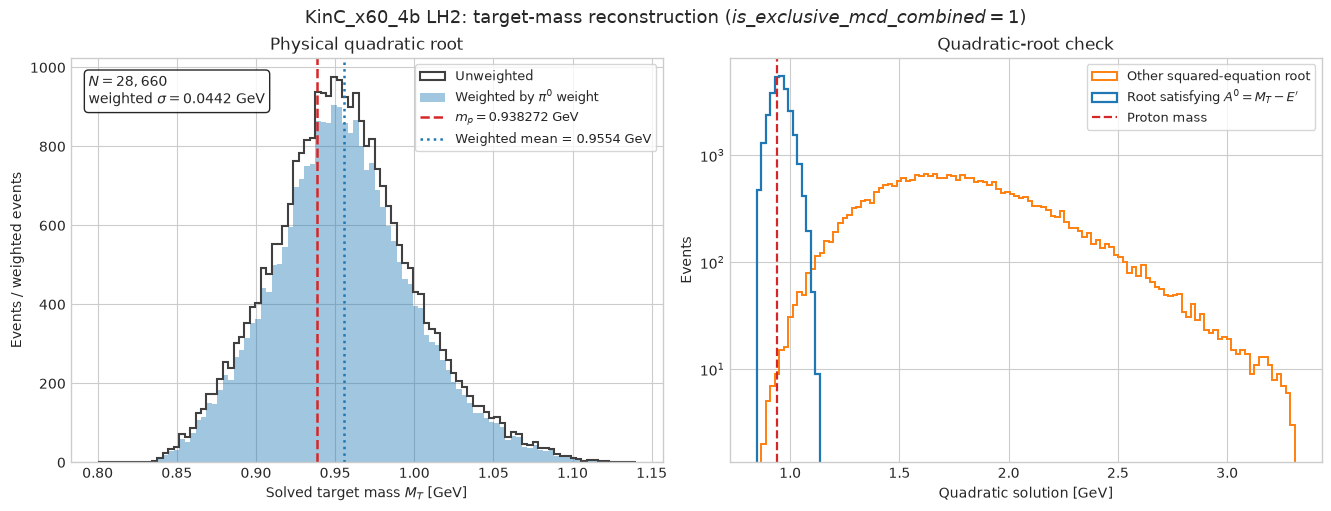

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), constrained_layout=True)

bins = np.linspace(0.80, 1.14, 100)
axes[0].hist(m, bins=bins, histtype="step", linewidth=1.5, color="0.25", label="Unweighted")
axes[0].hist(m, bins=bins, weights=w, histtype="stepfilled", alpha=0.42, color="tab:blue", label=r"Weighted by $\pi^0$ weight")
axes[0].axvline(M_P, color="tab:red", linestyle="--", linewidth=1.8, label=rf"$m_p={M_P:.6f}$ GeV")
axes[0].axvline(weighted_mean, color="tab:blue", linestyle=":", linewidth=1.8, label=rf"Weighted mean = {weighted_mean:.4f} GeV")
axes[0].set(xlabel=r"Solved target mass $M_T$ [GeV]", ylabel="Events / weighted events", title="Physical quadratic root")
axes[0].legend(frameon=True, fontsize=9)
axes[0].text(
    0.03, 0.96, rf"$N={len(m):,}$" + "\n" + rf"weighted $\sigma={weighted_std:.4f}$ GeV",
    transform=axes[0].transAxes, va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

all_roots = np.concatenate((m, m_alt))
root_min, root_max = np.quantile(all_roots, [0.001, 0.999])
root_bins = np.linspace(root_min, root_max, 120)
axes[1].hist(m_alt, bins=root_bins, histtype="step", linewidth=1.4, color="tab:orange", label="Other squared-equation root")
axes[1].hist(m, bins=root_bins, histtype="step", linewidth=1.6, color="tab:blue", label="Root satisfying $A^0=M_T-E'$")
axes[1].axvline(M_P, color="tab:red", linestyle="--", linewidth=1.6, label="Proton mass")
axes[1].set(xlabel=r"Quadratic solution [GeV]", ylabel="Events", title="Quadratic-root check")
axes[1].set_yscale("log")
axes[1].legend(frameon=True, fontsize=9)

fig.suptitle(r"KinC_x60_4b LH2: target-mass reconstruction ($is\_exclusive\_mcd\_combined=1$)", fontsize=13)
PLOT_FILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_FILE, dpi=180, bbox_inches="tight")
print(f"Saved plot to {PLOT_FILE}")
plt.show()

## Correlation between the two quadratic roots

This 2D histogram shows the event-by-event correlation between $M_-=E'-\sqrt{|\mathbf{p}'|^2+A^2}$ and $M_+=E'+\sqrt{|\mathbf{p}'|^2+A^2}$ for the same MCD-selected sample. Bin contents use the existing $\pi^0$ weights, and the logarithmic color scale makes the lower-density structure visible.

Weighted root correlation: -0.584230
Saved 2D root-correlation plot to /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/script/target_mass_two_roots_correlation.png


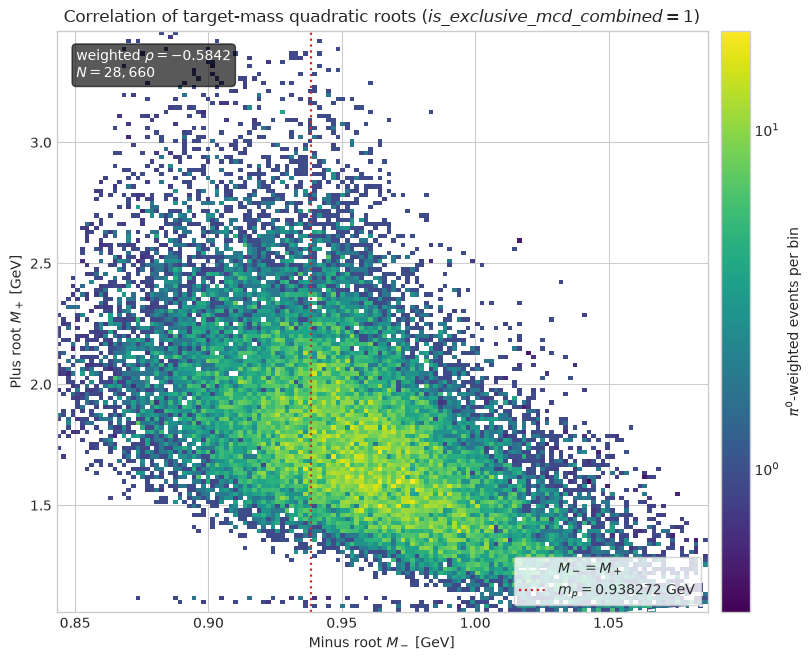

In [13]:
from matplotlib.colors import LogNorm

CORRELATION_PLOT_FILE = PLOT_FILE.with_name("target_mass_two_roots_correlation.png")
root_minus_selected = mass_root_minus[selected]
root_plus_selected = mass_root_plus[selected]

def weighted_correlation(x, y, weights):
    x_mean = np.average(x, weights=weights)
    y_mean = np.average(y, weights=weights)
    covariance = np.average((x - x_mean) * (y - y_mean), weights=weights)
    x_variance = np.average((x - x_mean) ** 2, weights=weights)
    y_variance = np.average((y - y_mean) ** 2, weights=weights)
    return covariance / np.sqrt(x_variance * y_variance)

root_correlation = weighted_correlation(root_minus_selected, root_plus_selected, w)
x_limits = np.quantile(root_minus_selected, [0.001, 0.999])
y_limits = np.quantile(root_plus_selected, [0.001, 0.999])

fig_corr, ax_corr = plt.subplots(figsize=(8.0, 6.5), constrained_layout=True)
hist2d = ax_corr.hist2d(
    root_minus_selected, root_plus_selected,
    bins=(140, 140), range=(x_limits, y_limits), weights=w,
    norm=LogNorm(), cmap="viridis",
)
colorbar = fig_corr.colorbar(hist2d[3], ax=ax_corr, pad=0.02)
colorbar.set_label(r"$\pi^0$-weighted events per bin")

diagonal_min = max(x_limits[0], y_limits[0])
diagonal_max = min(x_limits[1], y_limits[1])
ax_corr.plot(
    [diagonal_min, diagonal_max], [diagonal_min, diagonal_max],
    color="white", linestyle="--", linewidth=1.4, label=r"$M_-=M_+$",
)
ax_corr.axvline(M_P, color="tab:red", linestyle=":", linewidth=1.6, label=rf"$m_p={M_P:.6f}$ GeV")
ax_corr.axhline(M_P, color="tab:red", linestyle=":", linewidth=1.6)
ax_corr.set(
    xlim=x_limits, ylim=y_limits,
    xlabel=r"Minus root $M_-$ [GeV]",
    ylabel=r"Plus root $M_+$ [GeV]",
    title=r"Correlation of target-mass quadratic roots ($is\_exclusive\_mcd\_combined=1$)",
)
ax_corr.text(
    0.03, 0.97, rf"weighted $\rho={root_correlation:.4f}$" + "\n" + rf"$N={selected.sum():,}$",
    transform=ax_corr.transAxes, va="top", ha="left", color="white",
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.65),
)
ax_corr.legend(loc="lower right", frameon=True)
fig_corr.savefig(CORRELATION_PLOT_FILE, dpi=180, bbox_inches="tight")
print(f"Weighted root correlation: {root_correlation:.6f}")
print(f"Saved 2D root-correlation plot to {CORRELATION_PLOT_FILE}")
plt.show()
